# Lesson 6: Three or More Independent Groups

**Course:** hypothesis_testing_and_statistical_inference  
**Prerequisites:** Basic Python and descriptive statistics

This lesson follows a repeatable workflow: define the question, encode the design,
check assumptions, estimate the effect, quantify uncertainty, test the claim, and
communicate both statistical and practical meaning.


## Learning objectives

1. Run one-way ANOVA and quantify the omnibus effect with omega-squared
2. Use Welch ANOVA or Kruskal–Wallis when appropriate
3. Follow a significant omnibus test with multiplicity-aware comparisons
4. Distinguish planned contrasts from exploratory post-hoc testing


## Setup

Run this cell first. Every example uses a fixed random seed so results are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Work whether the kernel starts in the course root or a level folder.
working_dir = Path.cwd()
COURSE_ROOT = working_dir if (working_dir / "data").exists() else working_dir.parent
DATA_DIR = COURSE_ROOT / "data"

rng = np.random.default_rng(20260920)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.precision", 4)


## 6.1 The omnibus question

One-way ANOVA tests $H_0:\mu_1=\cdots=\mu_k$. Rejection means at least one mean differs; it does not say
which. The F statistic compares between-group variation with within-group variation. Independence is a
design assumption; residual shape and variance patterns are model diagnostics.


In [2]:
anes = pd.read_csv(DATA_DIR / "anes96_clean.csv")
df = anes[["party_group", "age_years"]].dropna().rename(
    columns={"party_group": "group", "age_years": "score"})
groups = {name: part["score"].to_numpy() for name, part in df.groupby("group", observed=True)}

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
model = ols("score ~ C(group)", data=df).fit()
table = anova_lm(model, typ=2)
ss_between = table.loc["C(group)", "sum_sq"]
ss_error = table.loc["Residual", "sum_sq"]
df_between = table.loc["C(group)", "df"]
ms_error = ss_error/table.loc["Residual", "df"]
omega2 = (ss_between-df_between*ms_error)/(ss_between+ss_error+ms_error)
display(table)
print(f"Omega-squared: {omega2:.3f}")


,sum_sq,df,F,PR(>F)
C(group),417.3136,2.0,0.7732,0.4618
Residual,253927.9057,941.0,NaN,NaN


Omega-squared: -0.000


     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1      group2   meandiff p-adj   lower  upper  reject
-------------------------------------------------------------
   Democrat Independent   0.9186 0.9424 -5.6568  7.494  False
   Democrat  Republican   1.3556 0.4304 -1.2127 3.9239  False
Independent  Republican    0.437 0.9868 -6.1764 7.0504  False
-------------------------------------------------------------


/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


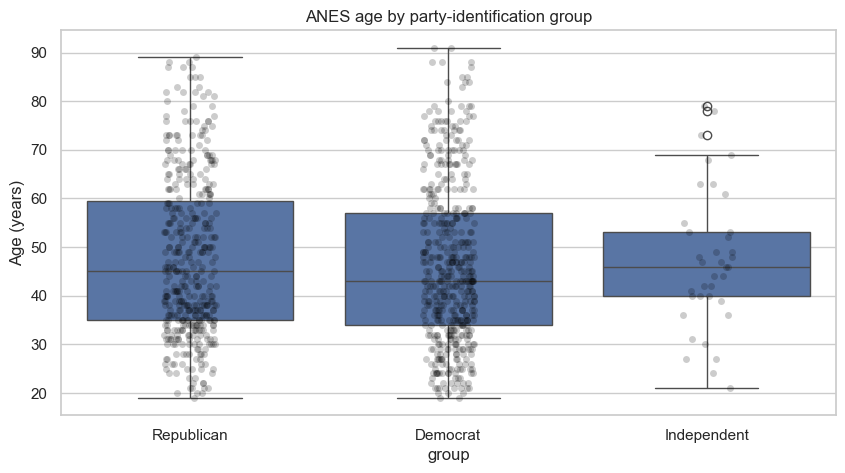

In [3]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(df["score"], df["group"], alpha=.05)
print(tukey)

fig, ax = plt.subplots()
sns.boxplot(data=df, x="group", y="score", ax=ax)
sns.stripplot(data=df, x="group", y="score", color="black", alpha=.2, ax=ax)
ax.set(title="ANES age by party-identification group", ylabel="Age (years)")
plt.show()


## 6.2 Robust alternatives

- **Welch ANOVA:** compares means with unequal variances; follow with Games–Howell when available.
- **Kruskal–Wallis:** rank-based omnibus test for independent groups; follow with adjusted pairwise
  rank tests. It is sensitive to distributional differences, not exclusively medians.


In [4]:
from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.multitest import multipletests
from itertools import combinations

welch = anova_oneway(list(groups.values()), use_var="unequal")
kw = stats.kruskal(*groups.values())
n_total, k = len(df), len(groups)
epsilon2 = max(0, (kw.statistic-k+1)/(n_total-k))

comparisons = []
for a, b in combinations(groups, 2):
    result = stats.mannwhitneyu(groups[a], groups[b], alternative="two-sided")
    comparisons.append([a, b, result.statistic, result.pvalue])
comp = pd.DataFrame(comparisons, columns=["group 1", "group 2", "U", "raw p"])
comp["Holm p"] = multipletests(comp["raw p"], method="holm")[1]
print(f"Welch ANOVA: F={welch.statistic:.3f}, p={welch.pvalue:.4g}")
print(f"Kruskal-Wallis: H={kw.statistic:.3f}, p={kw.pvalue:.4g}, epsilon²={epsilon2:.3f}")
comp


Welch ANOVA: F=0.764, p=0.4686
Kruskal-Wallis: H=1.628, p=0.4432, epsilon²=0.000


,group 1,group 2,U,raw p,Holm p
0,Democrat,Independent,8438.5,0.5078,1.0000
1,Democrat,Republican,97558.0,0.2343,0.7028
2,Independent,Republican,7921.5,0.8254,1.0000


## Worked example and interpretation

### Global and pairwise questions

The ANES example groups respondent ages by three party-identification categories. A one-way ANOVA asks whether all population group means could be equal; it gives F = 0.773 and p = 0.462. The estimated omega-squared is essentially zero (a slightly negative sample estimate is conventionally read as no detectable explained variation). This global result does not identify any particular pair. Tukey's adjusted pairwise comparisons all retain zero in their intervals, matching the weak omnibus evidence. The box-and-point chart shows the distributions behind the summary.

### Sensitivity to assumptions

The notebook repeats the global question with Welch ANOVA, which allows unequal variances (p = 0.469), and Kruskal–Wallis, which uses ranks (p = 0.443). Holm-adjusted rank comparisons also show no clear pairwise difference. Agreement here strengthens the limited conclusion that this dataset gives little evidence of age differences by party category; it does **not** prove the group distributions are identical. Test choice still depends on the estimand, independent respondent sampling, variance pattern, shape, and whether ranks or means answer the research question.

## Practice and solution

**Practice.** The omnibus ANOVA p-value is .002. Can you report that group C exceeds group A?

<details><summary>Solution</summary>

Not from the omnibus result alone. Use a pre-specified contrast or a multiplicity-controlled post-hoc
comparison and report the estimated difference with its interval. The omnibus test only establishes
that not all population means are equal.
</details>

## Key takeaways

- Omnibus tests answer a global question; post-hoc tests locate differences.
- Use omega-squared or another effect size, not only F and p.
- Choose robust methods based on the estimand and diagnostics.


## Reproducibility checklist

- State the population, outcome, groups, and sampling unit.
- State $H_0$, $H_1$, alpha, and whether the test is one- or two-sided before looking at results.
- Verify independence from the design; use plots and diagnostics for distributional assumptions.
- Report the estimate, confidence interval, effect size, test statistic, degrees of freedom, and exact p-value.
- Separate statistical evidence from practical importance and acknowledge design limitations.
